<a href="https://colab.research.google.com/github/Pauladrea03/SolarPV_Project/blob/main/c_modelos_ML%26DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Introducción

La finalidad de este proyecto es desarrollar un modelo predictivo capaz de estimar con alta precisión la potencia de corriente alterna (CA) generada por un sistema solar fotovoltaico, utilizando datos históricos de operación y variables asociadas a las condiciones del módulo.

El conjunto de datos empleado proviene del sistema fotovoltaico del grupo GECAD (ISEP, Porto, Portugal). Dicho sistema estaba inicialmente constituido por dos paneles solares con una potencia total de 400 W; sin embargo, tras la avería de uno de ellos el 4 de enero de 2013, la potencia instalada efectiva se redujo a aproximadamente 200 W. Los datos fueron registrados con un periodo de muestreo de 5 minutos durante todo el año 2013.

El objetivo central de este trabajo es predecir la potencia eléctrica generada a partir de las variables más relevantes del dataset, disponible en el repositorio: https://site.ieee.org/pes-iss/data-sets/#ramos2012a
. Para ello, se implementan y comparan distintos enfoques de modelado. En primer lugar, se utiliza un modelo de aprendizaje automático basado en regresión Ridge; posteriormente, se emplea un Random Forest Regressor. Finalmente, se desarrolla un modelo más avanzado basado en redes neuronales LSTM, cuyo desempeño se compara con el de los modelos previos con el fin de determinar cuál ofrece la mejor capacidad predictiva.

#Librerias

In [ ]:
pip install scikeras


In [ ]:
# Librerías de manipulación de datos
import pandas as pd
import numpy as np
import os
import random
# Librerías de visualización
import matplotlib.pyplot as plt

import gdown
import sqlite3
from sklearn.model_selection import train_test_split
from math import sqrt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import uniform, randint
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import TimeSeriesSplit
from tensorflow.keras.layers import LSTM, Dense, Dropout
from scikeras.wrappers import KerasRegressor
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers, callbacks, models, optimizers

# **#Entrega 3**

##Definiciones y contextualización

De acuerdo con [1], la Regresión Ridge (o regularización de Tikhonov) es una versión regularizada de la Regresión Lineal. El modelo de Regresión Ridge se define al añadir un término de regularización a la función de costo de la Regresión Lineal. Este término obliga al algoritmo de aprendizaje no solo a ajustarse a los datos, sino también a mantener los pesos del modelo lo más pequeños posible. El término de regularización se basa en la norma L2 del vector de pesos (w). El hiperparámetro α (alfa) controla la cantidad de regularización que se desea aplicar al modelo: Si α=0, la Regresión Ridge es simplemente Regresión Lineal; Si α es muy grande, todos los pesos terminan muy cerca de cero, resultando en una línea plana que pasa por la media de los datos. Al aumentar α, se obtienen predicciones más planas (menos extremas), lo que reduce la varianza del modelo pero aumenta su sesgo. La Regresión Ridge puede implementarse utilizando una ecuación de forma cerrada (solución directa) o mediante Descenso de Gradiente. Para el Descenso de Gradiente, se añade αw al vector de gradiente MSE.

Esta herramienta se usó debido a que permite mitigar el soreajuste y manejar la multicolinealidad. En el contexto de la serie de tiempo estudiada, se utilizan variables predictoras altamente correlacionadas entre sí, la regresión Ridge puede ayudar a construir un modelo más robusto al reducir la magnitud de los coeficientes.

Por otra parte, el Random Forest es un algoritmo de Machine Learning que forma parte de la categoría de Ensemble Learning. En [1] se dice que los Random Forests funcionan entrenando muchos Árboles de Decisión en subconjuntos aleatorios de las características y luego promediando sus predicciones. Un conjunto de predictores (como los árboles de decisión) se denomina ensemble. Agregar las predicciones de un grupo de predictores a menudo conduce a mejores predicciones que con el mejor predictor individual. El algoritmo de Random Forest introduce aleatoriedad adicional al hacer crecer los árboles. En lugar de buscar la mejor característica posible al dividir un nodo (como hace un Árbol de Decisión normal, ver Capítulo 6), busca la mejor característica dentro de un subconjunto aleatorio de características. Esta diversidad de árboles se traduce en una reducción de la varianza a cambio de un sesgo ligeramente mayor, lo que generalmente resulta en un modelo mejor en general. Los Random Forests a menudo son una técnica simple pero muy poderosa para resolver la mayoría de los problemas de ML. Los Random Forests facilitan la medición de la importancia relativa de cada característica. Scikit-Learn mide esta importancia observando cuánto reducen la impureza en promedio los nodos del árbol que utilizan esa característica.

La clase RandomForestRegressor hereda casi todos los hiperparámetros de las clases DecisionTreeClassifier (para controlar cómo crecen los árboles) y BaggingClassifier (para controlar el conjunto).
Para el ajuste fino (fine-tuning) de modelos de Bosques Aleatorios, se utiliza comúnmente la búsqueda en cuadrícula (GridSearchCV) o la búsqueda aleatoria (RandomizedSearchCV). Para el modelo de Random Forest encontramos hiperparámetros como:
*   n_estimators: Número de árboles en el bosque, cada árbol es un modelo independiente, el bosque combina las predicciones de todos los árboles (promedio), a mayor cantidad de árboles mejor generalización (menos varianza) pero mayor tiempo de entrenamiento.

*   max_depth: Profundidad máxima de cada árbol. Este hiperparámetro controla cuántas divisiones puede hacer cada árbol. Árboles muy profundos aprenden patrones complejos, árboles poco profundos son más simples

*   min_samples_split: Mínimo de muestras requeridas para dividir un nodo. Determina cuántas observaciones debe tener un nodo antes de intentar dividirlo. Valores pequeños tiene más divisiones (árboles más detallados), valores grandes tienen menores divisiones.

*   min_samples_leaf: Mínimo de muestras requeridas en cada hoja terminal. Si es 1 cada hoja representa una observación, lo que genera riesgo de sobreajuste. Si es mayor cada hoja agrupa más observaciones, esto suaviza las predicciones

El modelo de Random Forest se utilizó ya que puede capturar patrones y relaciones complejas y no lineales entre las diferentes variables predictoras sin necesidad de especificar manualmente la forma de la relación. Al ser un modelo de ensemble, es robusto y menos propenso al sobreajuste; además, es muy eficaz cuando se tienen múltiples variables predictoras.

In [ ]:
file_id = "1fAipOfV3JhNaUvHk9fmVshn-mMFPGfby" #identificador del archivo almacenado en google drive con acceso público
url = f"https://drive.google.com/uc?id={file_id}"
output = "data_final.db"
gdown.download(url, output, quiet=False)

# Conexión a la BD
conn = sqlite3.connect(output)

Downloading...
From: https://drive.google.com/uc?id=1fAipOfV3JhNaUvHk9fmVshn-mMFPGfby
To: /content/data_final.db
100%|██████████| 59.7M/59.7M [00:01<00:00, 58.1MB/s]


In [ ]:
df = pd.read_sql("SELECT * FROM df;", conn)
conn.close()
print(df.shape)

(61152, 23)


In [ ]:
df.head()

,radiacion_solar,temperatura_modulo,tension_ac,tension_dc,fecha,fecha_completa,hora,dia_semana,mes,potencia_ac,...,hora_cos,P_lag3,P_lag6,P_lag12,P_roll_mean_30min,P_roll_min_30min,P_roll_max_30min,P_roll_mean_1h,P_roll_std_30min,P_roll_std_1h
0,87.029147,16.367407,92.136134,9.188424,2013-01-02 07:00:00,2013-01-02,7.0,2,1,3.363817,...,-0.970942,0.000000,0.0,0.0,3.363817,3.363817,3.363817,3.363817,0.0,0.0
1,87.029147,16.367407,92.136134,9.188424,2013-01-02 07:05:00,2013-01-02,7.0,2,1,3.363817,...,-0.970942,0.000000,0.0,0.0,3.363817,3.363817,3.363817,3.363817,0.0,0.0
2,87.029147,16.367407,92.136134,9.188424,2013-01-02 07:10:00,2013-01-02,7.0,2,1,3.363817,...,-0.970942,0.000000,0.0,0.0,3.363817,3.363817,3.363817,3.363817,0.0,0.0
3,87.029147,16.367407,92.136134,9.188424,2013-01-02 07:15:00,2013-01-02,7.0,2,1,3.363817,...,-0.970942,3.363817,0.0,0.0,3.363817,3.363817,3.363817,3.363817,0.0,0.0
4,87.029147,16.367407,92.136134,9.188424,2013-01-02 07:20:00,2013-01-02,7.0,2,1,3.363817,...,-0.970942,3.363817,0.0,0.0,3.363817,3.363817,3.363817,3.363817,0.0,0.0


##Modelos de Machine Learning

In [ ]:
# Nos aseguramos de tener la fecha en el formato correcto y ordenamos el dataset en orden cronológico
df['fecha'] = pd.to_datetime(df['fecha'])
df = df.sort_values('fecha')

# Variables predictoras y objetivo
target = 'potencia_ac'

features = [
    'radiacion_solar', 'temperatura_modulo', 'tension_ac', 'tension_dc',
    'hora', 'dia_semana', 'mes', 'tendencia_potencia', 'periodo_potencia',
    'hora_sin', 'hora_cos',
    'P_lag3', 'P_lag6', 'P_lag12',
    'P_roll_mean_30min', 'P_roll_min_30min', 'P_roll_max_30min',
    'P_roll_mean_1h', 'P_roll_std_30min', 'P_roll_std_1h'
]

X = df[features]
y = df[target]

TimeSeriesSplit genera pliegues temporales que respetan el orden: en cada fold, el train es anterior en el tiempo al test. Con n_splits=5 se producen 5 iteraciones internas para la búsqueda de hiperparámetros. Usar TimeSeriesSplit evita usar el futuro para predecir el pasado y se emulan reentrenamientos periódicos

In [ ]:
cv = TimeSeriesSplit(n_splits=5) #definimos el timeseriessplit para el df temporal
#n_splits=5, es decir, test seria 1/(n_splits+1) del total por cada fold

Ridge es una regresión lineal con regularización L2. La regularización L2 penaliza los coeficientes grandes (los vuelve 0) para evitar el sobreajuste, cuanto más grande es alpha, más fuerte es la penalización, cuanto más pequeño es alpha, más se parece a una regresión lineal normal (sin regularización). Para el hiperparámetro alpha se realizó optimización de hiperparámetros usando RandomizedSearchCV el cual se encarga de probar 15 combinaciones aleatorias de cada hiperparámetro y elige la que menos RMSE promedio tenga durante la validación temporal.

In [ ]:
pipe_lr = Pipeline([
    ('scaler', StandardScaler()), #estandarización para modelo de regresión Ridge
    ('model', Ridge())
])

param_dist_lr = {
    'model__alpha': uniform(0.001, 10) #busqueda aleatoria para el alpha (L2 strength)
}
#Se usa RandomizedSearchCV porque es mas eficiente que GridSearch
search_lr = RandomizedSearchCV(
    pipe_lr,
    param_distributions=param_dist_lr, #exploracion entre 0.001 y 10
    n_iter=15, #número de combinaciones muestreadas de la distribucion
    cv=cv, #hace que cada combinación de hiperparámetros se evalúe usando validación temporal
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42
)
search_lr.fit(X, y) #entrenamos el modelo y seleccionamos el mejor para elegir el mejor alpha

print("Mejor modelo Ridge:", search_lr.best_params_)


Mejor modelo Ridge: {'model__alpha': np.float64(8.325426408004217)}


Para el modelo de Random Forest encontramos hiperparámetros como n_estimators, max_depth, min_samples_split y min_samples_leaf. Para estos hiperparámetros se realizó la optimización de hiperparámetros usando RandomizedSearchCV el cual se encarga de probar 15 combinaciones aleatorias de cada hiperparámetro y elige la que menos RMSE promedio tenga durante la validación temporal.

In [ ]:
pipe_rf = Pipeline([
    ('model', RandomForestRegressor(random_state=42, n_jobs=-1))
])

#Hiperparámetros muestreados en Random Forest
param_dist_rf = {
    'model__n_estimators': randint(100, 200),
    'model__max_depth': randint(10, 20),
    'model__min_samples_split': randint(2, 10),
    'model__min_samples_leaf': randint(1, 4)
}

search_rf = RandomizedSearchCV(
    pipe_rf,
    param_distributions=param_dist_rf,
    n_iter=15,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42
)
search_rf.fit(X, y)

print("Mejor modelo Random Forest:", search_rf.best_params_)

Mejor modelo Random Forest: {'model__max_depth': 18, 'model__min_samples_leaf': 3, 'model__min_samples_split': 6, 'model__n_estimators': 150}


In [ ]:
# Dividir en entrenamiento y test (último 20%)
split_index = int(len(X) * 0.8) #se reserva el ultimo 20% del dataset para test conservando la temporalidad
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

# Entrenar modelos con los mejores parámetros encontrados en las busquedas
best_lr = search_lr.best_estimator_
best_rf = search_rf.best_estimator_

#se ajustan los modelos en el set de entrenamineto final
best_lr.fit(X_train, y_train)
best_rf.fit(X_train, y_train)

#función de evaluación
def evaluate_train_test(model, X_train, y_train, X_test, y_test, name):
    # Predicciones
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # Métricas: RMSE, MAE, R2 (train y test para evaluar subajuste y sobreajuste)
    metrics = {
        "Model": name,
        "RMSE_train": np.sqrt(mean_squared_error(y_train, y_pred_train)),
        "RMSE_test": np.sqrt(mean_squared_error(y_test, y_pred_test)),
        "MAE_train": mean_absolute_error(y_train, y_pred_train),
        "MAE_test": mean_absolute_error(y_test, y_pred_test),
        "R2_train": r2_score(y_train, y_pred_train),
        "R2_test": r2_score(y_test, y_pred_test)
    }

    return metrics

# Evaluar ambos modelos
results_lr = evaluate_train_test(best_lr, X_train, y_train, X_test, y_test, "Regresion Ridge")
results_rf = evaluate_train_test(best_rf, X_train, y_train, X_test, y_test, "Random Forest")

# Convertir a DataFrame para visualizar
import pandas as pd
results_df = pd.DataFrame([results_lr, results_rf])
print(results_df)

NameError: name 'X' is not defined

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import pandas as pd # Para manejar los nombres de las columnas

# Asumiendo que ya has ejecutado tu código de RandomizedSearchCV
# y 'search_rf' contiene el resultado de la búsqueda.

# 1. Acceder al mejor modelo de Random Forest
best_rf_model = search_rf.best_estimator_.named_steps['model']

# 2. Extraer un árbol individual del bosque
# Por ejemplo, el primer árbol (índice 0)
tree_to_visualize = best_rf_model.estimators_[0]

# Opcional: Extraer los nombres de las características para una mejor visualización
# Asegúrate de que X sea un DataFrame o que X.columns esté disponible
feature_names = X.columns.tolist()

# 3. Visualizar el árbol
plt.figure(figsize=(20, 10)) # Ajusta el tamaño para que sea legible
plot_tree(tree_to_visualize,
          feature_names=feature_names,
          filled=True,
          rounded=True,
          fontsize=8,
          max_depth=5) # Puedes limitar la profundidad para que no sea demasiado grande
plt.title(f"Árbol de Decisión Individual del Random Forest (depth limitado a 5)")
plt.show()

# También puedes ver la profundidad total de este árbol si no la limitas en plot_tree
print(f"Profundidad total del árbol visualizado: {tree_to_visualize.get_depth()}")

Ambos modelos presentan un desempeño sobresaliente, con valores de R² superiores al 97%, lo que indica una alta capacidad explicativa respecto a la variación observada en la potencia. No obstante, existen diferencias significativas en la naturaleza del ajuste y en la precisión alcanzada por cada uno.

La regresión Ridge mostró un rendimiento muy sólido, explicando aproximadamente el 97.8% de la variabilidad en los datos de prueba y manteniendo una brecha mínima entre los errores de entrenamiento y validación. Este comportamiento refleja un modelo bien regularizado, estable y con excelente capacidad de generalización.

Dado que Ridge es un modelo lineal, su fortaleza radica en la simplicidad y la interpretabilidad: permite identificar de manera directa la influencia de cada variable sobre la potencia (por ejemplo, cómo cambia la potencia con la radiación o la temperatura del módulo). Sin embargo, al asumir relaciones lineales, el modelo no logra capturar completamente las interacciones no lineales y efectos combinados entre variables (como la interacción entre radiación, hora del día y temperatura).

En términos prácticos, el modelo Ridge logra predecir la potencia con un error promedio de aproximadamente 8.5 unidades, lo cual es satisfactorio, pero deja espacio para mejora si el sistema presenta comportamientos no lineales o dinámicos más complejos.

Por otro lado, el Random Forest presentó el mejor desempeño general. El modelo alcanzó un R² de 0.9915 en el conjunto de prueba, lo que implica que logra explicar más del 99% de la variabilidad observada en la potencia. Su error medio absoluto fue de apenas 1.75 unidades, lo que representa una mejora significativa en la precisión respecto al modelo lineal.

El bajo error en entrenamiento (RMSE = 2.05) sugiere que el modelo ajusta casi perfectamente los datos históricos, aunque esto genera un ligero sobreajuste, ya que el error en prueba aumenta a 5.25. Aun así, la diferencia es moderada y no compromete la capacidad predictiva. Este comportamiento es esperable en modelos no lineales complejos, especialmente en contextos con alta correlación temporal y múltiples variables explicativas.

El Random Forest capta patrones no lineales e interacciones entre variables que el modelo Ridge no puede modelar, por ejemplo, cómo la radiación solar combinada con la hora del día y la temperatura del módulo afecta la salida de potencia. Esto se traduce en una representación más realista del comportamiento físico del sistema.

Mientras que el modelo Ridge mantiene un error promedio de ±8.5 unidades, el Random Forest reduce ese margen a aproximadamente ±5.2, mejorando la precisión en casi un 40%. Ambos resultados demuestran que la combinación de variables seleccionadas describe de manera adecuada el comportamiento del sistema.

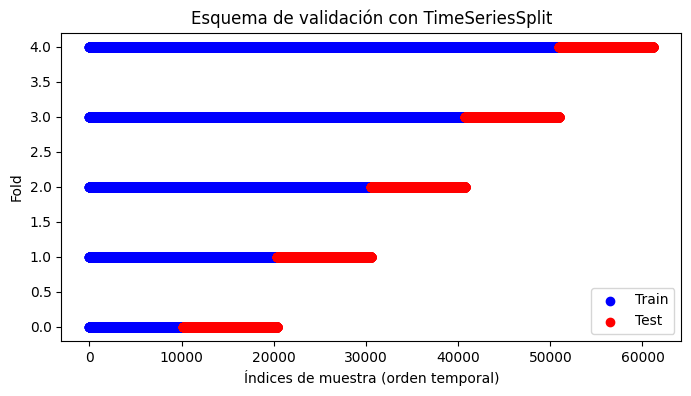

In [ ]:

fig, ax = plt.subplots(figsize=(8, 4))

for i, (train_idx, test_idx) in enumerate(cv.split(X)):
    ax.scatter(train_idx, [i]*len(train_idx), color='blue', label='Train' if i == 0 else "")
    ax.scatter(test_idx, [i]*len(test_idx), color='red', label='Test' if i == 0 else "")

ax.set_title("Esquema de validación con TimeSeriesSplit")
ax.set_xlabel("Índices de muestra (orden temporal)")
ax.set_ylabel("Fold")
ax.legend()
plt.show()


La imagen muestra el esquema de validación temporal usado por TimeSeriesSplit.

*   El eje X representa los índices de las muestras en orden temporal (los registros desde el primer día hasta el último).

*   El eje Y muestra los diferentes folds (divisiones) usados en la validación cruzada.

*   Los puntos azules (Train) indican las observaciones usadas para entrenar el modelo en cada fold.

*   Los puntos rojos (Test) son los datos más recientes usados para probar el modelo.

Cada fold va ampliando progresivamente la ventana de entrenamiento, respetando siempre la secuencia temporal. Esto simula cómo se comportaría el modelo en la práctica: se entrena con los datos históricos y se evalúa con datos futuros. Además, se puede observar que:

*   El primer fold entrena con los primeros datos y evalúa en el siguiente bloque temporal.

*   En cada fold sucesivo, el conjunto de entrenamiento crece, acumulando más historia.

*   El último fold utiliza casi todo el historial y prueba con el tramo final (cercano al presente).

Esta forma es ideal para problemas de predicción de series temporales, donde el objetivo es garantizar que el modelo generalice bien en el tiempo.

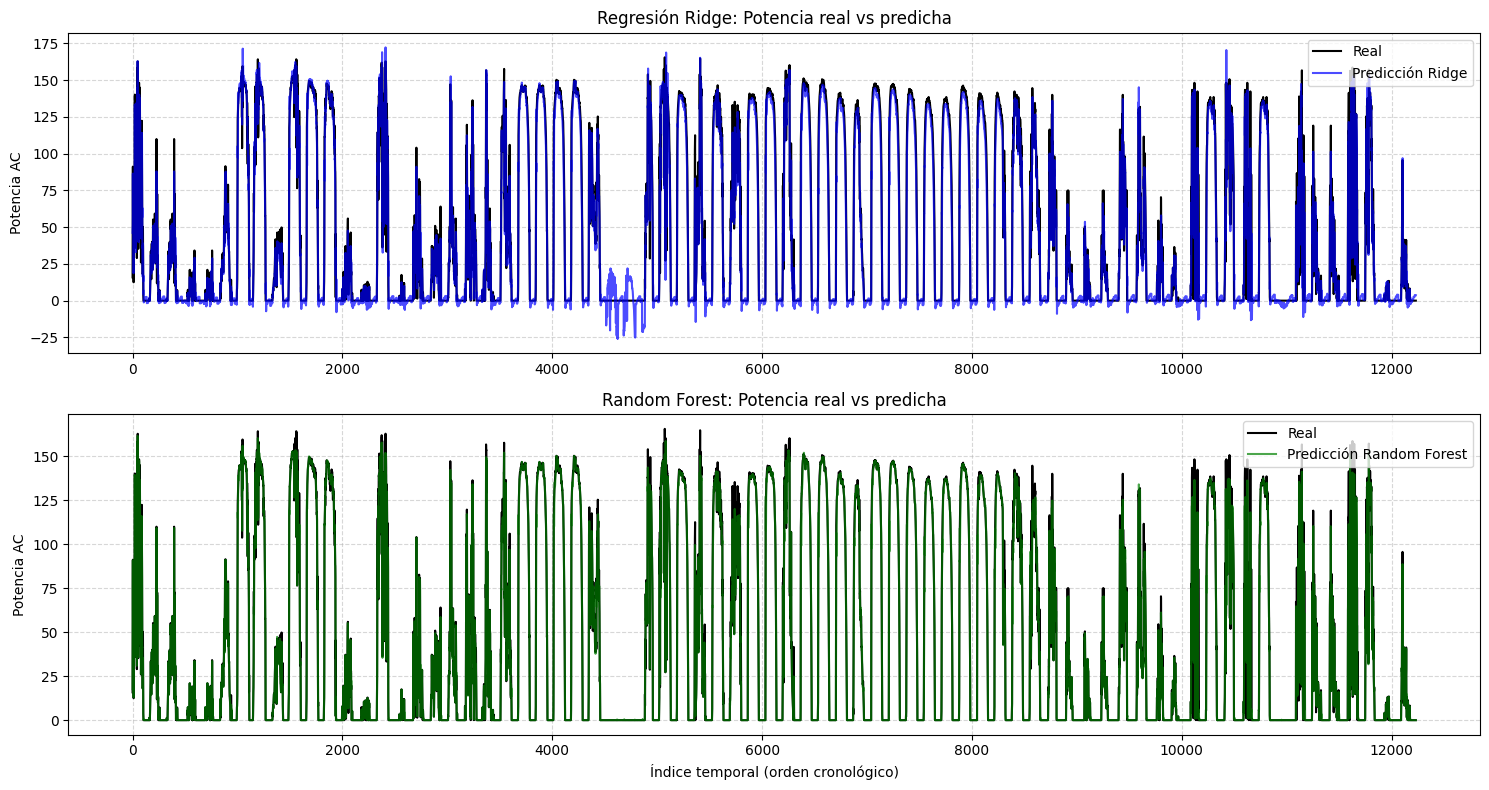

In [ ]:
import matplotlib.pyplot as plt

# Predicciones con los mejores modelos
y_pred_lr = best_lr.predict(X_test)
y_pred_rf = best_rf.predict(X_test)

# Crear figura
plt.figure(figsize=(15, 8))

# Gráfico para regresión Ridge
plt.subplot(2, 1, 1)
plt.plot(y_test.values, label='Real', color='black', linewidth=1.5)
plt.plot(y_pred_lr, label='Predicción Ridge', color='blue', alpha=0.7)
plt.title('Regresión Ridge: Potencia real vs predicha')
plt.ylabel('Potencia AC')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Gráfico para Random Forest
plt.subplot(2, 1, 2)
plt.plot(y_test.values, label='Real', color='black', linewidth=1.5)
plt.plot(y_pred_rf, label='Predicción Random Forest', color='green', alpha=0.7)
plt.title('Random Forest: Potencia real vs predicha')
plt.xlabel('Índice temporal (orden cronológico)')
plt.ylabel('Potencia AC')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


En los gráficos se observa la comparación entre la potencia real (línea negra) y las predicciones generadas por ambos modelos sobre el conjunto de prueba. En el caso del modelo de regresión Ridge, las predicciones siguen la tendencia general de la serie, pero muestran un comportamiento más suavizado y una menor capacidad para capturar los picos y variaciones abruptas en la potencia. Esto ocurre porque Ridge es un modelo lineal, que asume relaciones proporcionales entre las variables y no logra representar de manera óptima las interacciones no lineales propias de los datos.

Por su parte, el modelo de regresión Random Forest muestra una mayor precisión visual: las predicciones se ajustan mucho mejor a las fluctuaciones reales, reproduciendo tanto los picos de generación como las caídas bruscas. Esto refleja su capacidad para capturar relaciones no lineales y efectos complejos entre variables, lo cual se traduce en un mejor desempeño cuantitativo en las métricas de error.

En conjunto, la comparación gráfica confirma que el Random Forest ofrece una representación más fiel de la dinámica real de la potencia, mientras que Ridge, aunque más simple y estable, tiende a subestimar los valores extremos. Este comportamiento sugiere que, para etapas futuras, la aplicación de un modelo LSTM, capaz de incorporar la dependencia temporal entre observaciones, podría mejorar aún más el seguimiento de los patrones secuenciales y reducir las diferencias entre los valores reales y predichos.

##Conclusiones

En el análisis actual se implementaron dos modelos: Ridge Regression y Random Forest Regressor.
El modelo Ridge mostró un buen desempeño general (R² = 0.98), lo que indica que captura correctamente la relación lineal entre las variables, aunque presenta un mayor error en entrenamiento (RMSE = 9.96) comparado con Random Forest, lo que sugiere una menor capacidad para representar relaciones no lineales.

Por otro lado, el Random Forest alcanzó un R² = 0.99 y un RMSE en test de 5.25, mostrando una mejor capacidad predictiva y una mayor flexibilidad para modelar interacciones y patrones complejos en los datos. Sin embargo, al ser un modelo basado en árboles, no aprovecha completamente la dependencia temporal entre observaciones consecutivas, un aspecto fundamental en series de potencia.

Por esta razón, se propone evaluar próximamente un modelo LSTM (Long Short-Term Memory), diseñado para capturar patrones temporales y secuencias de largo plazo. Este enfoque podría mejorar la precisión y estabilidad de las predicciones, especialmente en contextos donde la potencia depende de la historia reciente de variables como la radiación o la temperatura. En consecuencia, la implementación de un modelo LSTM representa el siguiente paso lógico para optimizar la capacidad de forecasting del sistema y obtener predicciones más robustas ante variaciones temporales complejas.

# **#Entrega 4**

La versión final de la base de datos está compuesta de 61152 filas y 23 columnas. A continuación se muestra una breve descripción de las variables de la base de datos:


* **radiacion_solar:** radiación solar real medida (W/m^2)
* **temperatura_modulo**: temperatura del módulo (°C)
* **potencia_ac**: potencia AC generada (W)
* **tension_ac**: tensión de la red (V)
* **tension_dc**: tensión de entrada FV (V)
* **fecha**: fecha y hora combinadas en formato yyyy/mm/dd/ hh:mm:ss
* **fecha_completa**: fecha en formato yyyy/mm/dd/
* **hora**: hora en formato hh
* **dia_semana**: numeración de día de la semana [1,7]
* **mes**: numeración de día de la semana [1,12]
* **tendencia_potencia**: comportamiento a largo plazo del sistema [W]
* **periodo_potencia**: oscilaciones períodicas asociadas al amanecer y atardecer
* **hora_sin**: representación periódica de las horas
* **hora_cos**: representación periódica de las horas
* **P_lag3**: retardo cada 15 minutos
* **P_lag6**: retardo cada 30 minutos
* **P_lag12**: retardo cada 60 minutos
* **P_roll_mean_30min**: promedio de ventanas de 30 minutos
* **P_roll_min_30min**: mínimo de ventanas de 30 minutos
* **P_roll_max_30min**: máximo de ventanas de 30 minutos
* **P_roll_mean_1h**: promedio de ventanas de 1 hora
* **P_roll_std_30min**: desviación de ventanas de 30 minutos
* **P_roll_std_1h**: desviación de ventanas de 1 hora

##Carga de datos

In [ ]:
file_id = "1fAipOfV3JhNaUvHk9fmVshn-mMFPGfby" #identificador del archivo almacenado en google drive con acceso público
url = f"https://drive.google.com/uc?id={file_id}"
output = "data_final.db"
gdown.download(url, output, quiet=False)

# Conexión a la BD
conn = sqlite3.connect(output)

Downloading...
From: https://drive.google.com/uc?id=1fAipOfV3JhNaUvHk9fmVshn-mMFPGfby
To: /content/data_final.db
100%|██████████| 59.7M/59.7M [00:00<00:00, 65.8MB/s]


In [ ]:
df = pd.read_sql("SELECT * FROM df;", conn)
conn.close()
print(df.shape)

(61152, 23)


In [ ]:
df.head()

,radiacion_solar,temperatura_modulo,tension_ac,tension_dc,fecha,fecha_completa,hora,dia_semana,mes,potencia_ac,...,hora_cos,P_lag3,P_lag6,P_lag12,P_roll_mean_30min,P_roll_min_30min,P_roll_max_30min,P_roll_mean_1h,P_roll_std_30min,P_roll_std_1h
0,87.029147,16.367407,92.136134,9.188424,2013-01-02 07:00:00,2013-01-02,7.0,2,1,3.363817,...,-0.970942,0.000000,0.0,0.0,3.363817,3.363817,3.363817,3.363817,0.0,0.0
1,87.029147,16.367407,92.136134,9.188424,2013-01-02 07:05:00,2013-01-02,7.0,2,1,3.363817,...,-0.970942,0.000000,0.0,0.0,3.363817,3.363817,3.363817,3.363817,0.0,0.0
2,87.029147,16.367407,92.136134,9.188424,2013-01-02 07:10:00,2013-01-02,7.0,2,1,3.363817,...,-0.970942,0.000000,0.0,0.0,3.363817,3.363817,3.363817,3.363817,0.0,0.0
3,87.029147,16.367407,92.136134,9.188424,2013-01-02 07:15:00,2013-01-02,7.0,2,1,3.363817,...,-0.970942,3.363817,0.0,0.0,3.363817,3.363817,3.363817,3.363817,0.0,0.0
4,87.029147,16.367407,92.136134,9.188424,2013-01-02 07:20:00,2013-01-02,7.0,2,1,3.363817,...,-0.970942,3.363817,0.0,0.0,3.363817,3.363817,3.363817,3.363817,0.0,0.0


In [ ]:
df.dtypes

,0
radiacion_solar,float64
temperatura_modulo,float64
tension_ac,float64
tension_dc,float64
fecha,object
fecha_completa,object
hora,float64
dia_semana,int64
mes,int64
potencia_ac,float64


In [ ]:
df = df.copy()

# Crear correctamente la columna timestamp desde la columna real del dataset
df["timestamp"] = pd.to_datetime(df["fecha"])

# Asegurar orden temporal
df = df.sort_values("timestamp").reset_index(drop=True)

# Confirmación
print("timestamp min/max:", df["timestamp"].min(), df["timestamp"].max())
print("dtype:", df["timestamp"].dtype)
print("Primeros timestamps:", df["timestamp"].head(10).tolist())



timestamp min/max: 2013-01-02 07:00:00 2013-12-31 20:55:00
dtype: datetime64[ns]
Primeros timestamps: [Timestamp('2013-01-02 07:00:00'), Timestamp('2013-01-02 07:05:00'), Timestamp('2013-01-02 07:10:00'), Timestamp('2013-01-02 07:15:00'), Timestamp('2013-01-02 07:20:00'), Timestamp('2013-01-02 07:25:00'), Timestamp('2013-01-02 07:30:00'), Timestamp('2013-01-02 07:35:00'), Timestamp('2013-01-02 07:40:00'), Timestamp('2013-01-02 07:45:00')]


##Modelo de deep learning: LSTM

La Memoria a Largo y Corto Plazo (LSTM, por sus siglas en inglés Long Short-Term Memory) es un tipo de celda de memoria diseñada para superar las limitaciones de las redes neuronales recurrentes (RNN) simples, las cuales presentan dificultades para retener información durante largos periodos. Cuando se emplea como una “caja negra”, una celda LSTM opera de manera similar a una celda recurrente básica, pero con un rendimiento significativamente superior. Los modelos basados en LSTM suelen converger más rápido y capturar dependencias de largo plazo en los datos, lo que explica su éxito en tareas de análisis y predicción de series de tiempo.

Una celda LSTM se distingue por gestionar dos estados internos, lo que le permite decidir de forma eficiente qué información conservar y cuál descartar:

**Estado dividido:**
El estado interno se separa en dos vectores: el estado a corto plazo (short-term state) y el estado a largo plazo (long-term state).

**Mecanismo de compuertas:**
La idea central es que la celda aprende qué almacenar, qué eliminar y qué recuperar del estado a largo plazo. Para ello utiliza cuatro capas completamente conectadas que reciben como entrada el vector actual y el estado a corto plazo previo. Tres de estas capas actúan como compuertas:

* Compuerta de olvido: determina qué partes del estado a largo plazo deben eliminarse.

* Compuerta de entrada: decide qué información nueva debe incorporarse al estado a largo plazo.

* Compuerta de salida: regula qué información del estado a largo plazo se utiliza para generar la salida y el nuevo estado a corto plazo.

Estas compuertas emplean la función de activación logística, generando valores entre 0 y 1 que actúan como mecanismos de apertura o cierre mediante multiplicaciones elemento a elemento.

Para evaluar el rendimiento del modelo, se utilizan las siguientes métricas:

**Error Cuadrático Medio (RMSE)**

El RMSE es una métrica ampliamente utilizada y, en general, preferida para problemas de regresión. Proporciona una estimación del error típico cometido por el modelo y enfatiza los errores grandes debido a que se basa en la norma euclidiana (L2). Al calcular la raíz de la suma de los cuadrados de los errores, el RMSE mide la distancia euclidiana entre las predicciones y los valores reales.

**Error Absoluto Medio (MAE)**

El MAE es una métrica alternativa especialmente útil cuando existen numerosos valores atípicos (outliers). También conocido como desviación absoluta media, el MAE es menos sensible a los valores extremos que el RMSE. Al basarse en la norma L1, mide la distancia Manhattan entre las predicciones y los valores reales.

En modelos de Deep Learning, si el conjunto de entrenamiento contiene una alta proporción de valores atípicos, el uso del MAE puede provocar una convergencia más lenta y un modelo final menos preciso, dado que penaliza menos los errores grandes.

En términos generales, cuanto mayor es el índice de la norma utilizada, mayor es la penalización a los errores grandes. Por ello, el RMSE resulta más sensible a valores atípicos que el MAE, aunque suele preferirse cuando dichos valores son poco frecuentes (por ejemplo, en distribuciones similares a una curva normal).

*Todo lo anterior fue tomado de [1]*

Los LSTM son esenciales para series de tiempo, ya que permiten capturar las dependencias secuenciales a lo largo del tiempo, crucial para modelar con precisión la inercia térmica del módulo y los patrones de nubosidad transitoria, maximizando así la exactitud del pronóstico.

Este bloque inicial del código establece los parámetros fundamentales para asegurar la reproducibilidad y configuración del pipeline de modelado. En primera instancia, se fija una semilla global para todos los módulos que intervienen en operaciones aleatorias (Python, NumPy y TensorFlow). Esto garantiza que los resultados obtenidos en cada ejecución sean consistentes, un aspecto esencial para la validación científica y la comparación fiable entre modelos. Adicionalmente, se define un conjunto de parámetros globales que controlan el comportamiento del sistema: el nombre de las variables clave del dataset, el horizonte temporal utilizado para las divisiones de entrenamiento, validación y prueba, la longitud de la ventana temporal empleada para generar secuencias en el modelo LSTM, y la cantidad de particiones usadas en la validación cruzada temporal. Finalmente, se especifica el número de iteraciones del proceso de búsqueda aleatoria de hiperparámetros. Este conjunto de parámetros constituye la base operativa del pipeline y determina cómo se estructurará y evaluará el modelo.

In [ ]:
# Reproducibilidad
# Fijar una semilla común para todos los módulos aleatorios.
# Esto asegura que los resultados del modelo sean replicables en cada ejecución,
# incluyendo el comportamiento de NumPy, TensorFlow y Python.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# Parámetros
DATA_DF = df # DataFrame base de trabajo
TIMESTAMP_COL = "fecha" # Nombre de la columna temporal original en el dataset
TARGET_COL = "potencia_ac" # Variable objetivo que se desea predecir
# Tamaños de las particiones temporales para validación y prueba
TEST_SPLIT_DAYS = 30  # Últimos 30 días = Test
VAL_SPLIT_DAYS = 30 # 30 días previos al Test = Validación
# Ventana (lookback) de pasos anteriores usados para formar secuencias para LSTM
LOOKBACK_DEFAULT = 24  # Representa 24 pasos previos
TSCV_SPLITS = 3 # Número de particiones temporales para el Time Series Cross Validation
RANDOM_SEARCH_ITERS = 8 # Iteraciones que se ejecutarán en la búsqueda aleatoria de hiperparámetros
VERBOSE = 1

El conjunto de funciones presentadas constituye el módulo de preprocesamiento del pipeline. Su propósito es asegurar que los datos se encuentren en un formato consistente, ordenado y adecuadamente dividido para la posterior construcción del modelo de predicción. La función load_and_preprocess estandariza la columna temporal, ordena el dataset cronológicamente y genera una columna auxiliar con solo la fecha, lo cual facilita análisis agregados por día. Posteriormente, la función train_val_test_split_time realiza una partición temporal estricta del dataset, garantizando que los conjuntos de entrenamiento, validación y prueba reflejen la estructura real del paso del tiempo, evitando así fugas de información hacia el futuro. Finalmente, safe_scale_train_val_test aplica una estandarización de características basada exclusivamente en los datos de entrenamiento, lo que asegura un proceso de scaling correcto desde el punto de vista metodológico y evita sesgos en la validación y el test. En conjunto, este módulo prepara los datos bajo principios formales de manejo de series temporales, asegurando una base robusta para el modelado con LSTM.

In [ ]:
# Funciones de preprocesamiento

def load_and_preprocess(input_df, timestamp_col=TIMESTAMP_COL):
    """
    Convierte la columna temporal a datetime, ordena el dataset de forma cronológica
    y agrega una columna adicional con solo la fecha (sin hora).
    Se devuelve una copia del DataFrame original para no modificarlo directamente.
    """
    df = input_df.copy()
    df[timestamp_col] = pd.to_datetime(df[timestamp_col]) # Convertir la columna de timestamp a tipo datetime
    df = df.sort_values(timestamp_col).reset_index(drop=True)  # Asegurar orden cronológico ascendente
    df["date_only"] = df[timestamp_col].dt.date # Crear una columna que contiene solo la fecha
    return df

def train_val_test_split_time(df, timestamp_col=TIMESTAMP_COL, val_days=VAL_SPLIT_DAYS, test_days=TEST_SPLIT_DAYS):
    """
    Divide el DataFrame en tres subconjuntos: entrenamiento, validación y prueba,
    utilizando límites temporales (no aleatorios). Los últimos 'test_days'
    conforman el conjunto de prueba, y los días inmediatamente anteriores
    conforman el conjunto de validación.
    """
    last_ts = df[timestamp_col].max() # Última marca de tiempo disponible en el dataset
    test_start = last_ts - pd.Timedelta(days=test_days) + pd.Timedelta(minutes=5) # Inicio del conjunto de prueba
    val_start = test_start - pd.Timedelta(days=val_days) # Inicio del conjunto de validación
    # División temporal
    train_df = df[df[timestamp_col] < val_start].reset_index(drop=True)
    val_df = df[(df[timestamp_col] >= val_start) & (df[timestamp_col] < test_start)].reset_index(drop=True)
    test_df = df[df[timestamp_col] >= test_start].reset_index(drop=True)
    print(f"Train: {train_df.shape}, Val: {val_df.shape}, Test: {test_df.shape}")
    return train_df, val_df, test_df

def safe_scale_train_val_test(train_df, val_df, test_df, feature_cols):
    """
    Aplica estandarización (StandardScaler) únicamente usando la información del set
    de entrenamiento (fit). Luego transforma train, val y test usando ese mismo
    escalador, preservando el índice y demás columnas.
    """
    scaler = StandardScaler()
    scaler.fit(train_df[feature_cols]) # Ajustar solo con datos de entrenamiento para evitar fuga de información

    # Copias seguras de los dataframes
    train_s = train_df.copy()
    val_s = val_df.copy()
    test_s = test_df.copy()

    # transformamos SOLO las columnas numéricas/features
    train_s[feature_cols] = scaler.transform(train_df[feature_cols])
    val_s[feature_cols]   = scaler.transform(val_df[feature_cols])
    test_s[feature_cols]  = scaler.transform(test_df[feature_cols])

    return train_s, val_s, test_s, scaler

La primera parte esencial consiste en transformar la base de datos original en un conjunto de secuencias temporales aptas para alimentar una red LSTM.

La función make_sequences() recibe un dataframe, una lista de variables predictoras, la columna objetivo y un parámetro llamado lookback, que indica cuántos pasos históricos conforman cada ventana temporal.

Para evitar inconsistencias, el dataframe se agrupa por día. Esto garantiza que ninguna secuencia cruce un cambio de fecha, lo cual podría introducir discontinuidades, especialmente en series fotovoltaicas que tienen ciclos diarios muy marcados. Dentro de cada día, los registros se ordenan por timestamp y, si el número de filas es insuficiente para formar la ventana, ese día se descarta. Luego, se recorre el día creando ventanas de longitud lookback, donde cada ventana contiene las variables predictoras, y el valor objetivo corresponde al timestamp inmediato posterior al final de la ventana.

El resultado de esta función son tres estructuras:

X: matriz 3D con todas las ventanas generadas.

y: vector con los valores a predecir.

ts_list: lista con timestamps de cada predicción, útil para validar visualmente.

Esta transformación es fundamental para convertir una serie temporal en un problema de supervisión para redes neuronales.

In [ ]:
# Función para crear secuencias

def make_sequences(df, feature_cols, target_col=TARGET_COL, lookback=LOOKBACK_DEFAULT, timestamp_col=TIMESTAMP_COL):
    """
    Crea ventanas temporales para entrenar un modelo LSTM.
    La función garantiza que las ventanas NO crucen entre días,
    lo cual evita que haya saltos bruscos entre grupos que confundan al modelo.
    """
    X_list, y_list, ts_list = [], [], []

    # Separamos por día para evitar secuencias rotas
    for date, group in df.groupby("date_only"):
        # ordenar y resetear índice para garantizar posiciones 0..n-1
        group = group.sort_values(timestamp_col).reset_index(drop=True)
        n_rows = len(group)

        if n_rows <= lookback:
            # no hay suficiente datos en este día para formar al menos una ventana
            continue

        # convertir a numpy para indexar por posición
        arr_features = group[feature_cols].to_numpy()   # Matriz de features por día
        arr_target   = group[target_col].to_numpy()     # Vector del objetivo
        arr_times    = group[timestamp_col].to_numpy()  # Timestamps

         # Creamos ventanas deslizantes
        for i in range(n_rows - lookback):
            # Ventana de entrada X, últimos "lookback" registros
            X_window = arr_features[i : i + lookback] # Secuencia de entrada
            # Etiqueta y, valor ubicado justo después de la ventana
            y_value  = arr_target[i + lookback] # Valor a predecir
            # Timestamp asociado a esa etiqueta
            ts_value = arr_times[i + lookback] # Timestamp de ese valor

            # Agregamos secuencia, etiqueta y timestamp a las listas
            X_list.append(X_window)
            y_list.append(y_value)
            ts_list.append(ts_value)

    if len(X_list) == 0:
        # devuelve arrays vacíos con forma consistente
        return np.empty((0, lookback, len(feature_cols))), np.empty((0,)), []

    # Convertimos las listas en arrays listos para Keras
    X = np.stack(X_list)    # Dimensión: (n_samples, lookback, n_features)
    y = np.array(y_list)
    return X, y, ts_list

La función build_lstm_model() crea de manera flexible una arquitectura LSTM ajustable mediante hiperparámetros. El modelo recibe como entrada una matriz con forma (lookback, n_features), lo que significa que para cada predicción la red observa una secuencia de lookback pasos con todas las variables relevantes.

El número de capas LSTM se controla mediante el parámetro n_layers, y en cada iteración se define si una capa debe devolver secuencias (cuando no es la última). Además, se aplica dropout para reducir sobreajuste y una capa densa intermedia para mejorar la capacidad representativa del modelo. Finalmente, se añade una capa de salida lineal para generar un valor continuo de potencia.

El modelo se compila usando el optimizador Adam y métricas como RMSE y MAE, ambas esenciales para modelos de regresión. El uso de una función parametrizada facilita la exploración durante la búsqueda de hiperparámetros.

In [ ]:
# Construcción del modelo LSTM
def build_lstm_model(n_features, lookback, units=64, n_layers=1, dropout=0.2, lr=1e-3):
    """
    Crea un modelo LSTM parametrizable.
    """
    inp = layers.Input(shape=(lookback, n_features))  # Capa de entrada: secuencia de longitud "lookback" y n_features variables
    x = inp
    # Construcción de las capas LSTM
    for i in range(n_layers):
        return_seq = (i < n_layers - 1)  # Si no es la última capa, devolvemos secuencias para la siguiente LSTM
        units_i = units // (2**i) if n_layers > 1 else units  # En arquitecturas profundas, se reduce progresivamente el número de unidades
        x = layers.LSTM(units_i, return_sequences=return_seq)(x)  # Capa LSTM con sus unidades correspondientes
        x = layers.Dropout(dropout)(x) # Dropout para reducir sobreajuste

    x = layers.Dense(32, activation="relu")(x) # Capa densa intermedia para procesar las representaciones extraídas por la LSTM
    out = layers.Dense(1, activation="linear")(x) # Capa de salida: regresión a un valor continuo
    model = models.Model(inputs=inp, outputs=out)  # Ensamble del modelo
    optimizer = optimizers.Adam(learning_rate=lr)  # Optimizador Adam con tasa de aprendizaje ajustable
    # Configuración del modelo
    model.compile(optimizer=optimizer, loss="mse", metrics=[keras.metrics.RootMeanSquaredError(name="rmse"), "mae"])
    return model

Para evaluar adecuadamente modelos de series de tiempo no se puede usar una validación convencional aleatoria. Aquí se implementa TimeSeriesSplit, que divide los datos en pliegues respetando la estructura temporal.

Durante el proceso de Random Search se prueban distintas combinaciones de parámetros:

1. **units (número de neuronas de la capa LSTM)**

Define cuántas memorias internas (celdas LSTM) tiene la capa.

Valores altos (64–128) = mayor capacidad de aprendizaje y de capturar patrones complejos.

Valores bajos (32) = modelo más simple, menor riesgo de sobreajuste.

2. **n_layers (cantidad de capas LSTM apiladas)**

Indica cuántas capas LSTM se conectan consecutivamente.

1 capa = aprende dependencias temporales básicas.

2 capas = captura relaciones más profundas, pero aumenta el costo computacional y el riesgo de sobreajuste.

3. **dropout (porcentaje de neuronas apagadas aleatoriamente)**

Controla la regularización.

Valores entre 0.1 y 0.3 ayudan a evitar sobreajuste.

Dropout alto = mayor robustez, pero puede dificultar el aprendizaje.

Dropout bajo = riesgo de memorizar ruido del entrenamiento.

4. **batch_size (tamaño de los lotes de entrenamiento)**

Indica cuántas secuencias se usan para actualizar los pesos en cada paso.

Batch pequeño (16–32) = aprendizaje más estable en series temporales.

Batch grande = mayor velocidad pero menor sensibilidad a variaciones temporales.

5. **lr (learning rate o tasa de aprendizaje)**

Controla qué tan rápido ajusta sus pesos el optimizador Adam.

1e-3 = aprende más rápido, pero puede ser inestable.

5e-4 o 1e-4 = entrenamientos más estables y suaves, adecuados para LSTM.

6. **epochs (número máximo de recorridos completos sobre los datos)**

Define cuántas veces el modelo verá el dataset de entrenamiento.

Más épocas = más oportunidad de aprender patrones.

Sin embargo, se usa EarlyStopping, por lo que el entrenamiento se detiene automáticamente cuando ya no mejora el desempeño.

7. **early_stop_patience (número de épocas sin mejora antes de detener el entrenamiento)**

Evita sobreentrenamiento y ahorra tiempo.

Paciencia baja = riesgo de detener el aprendizaje antes de tiempo.

Paciencia alta = se permite entrenar más para mejorar la estabilidad.

Cada combinación se entrena y evalúa en múltiples folds temporales, obteniendo un RMSE promedio. La mejor configuración se selecciona como hiperparámetro óptimo y se utiliza posteriormente para entrenar el modelo final con los datos completos del entrenamiento.

In [ ]:
# Random Search + TimeSeriesSplit

def random_search_hyperparams_tscv(train_df_scaled, feature_cols, lookback,
    n_iter=RANDOM_SEARCH_ITERS, early_stop_patience=100, verbose=0):
    """
    Realiza Random Search sobre hiperparámetros usando TimeSeriesSplit(n_splits=TSCV_SPLITS).
    Retorna los mejores parámetros y el rmse promedio.
    """

    # 1) Generar todas las secuencias de train (sobre el dataframe escalado)
    X_full, y_full, _ = make_sequences(train_df_scaled, feature_cols, lookback=lookback)
    n_samples = X_full.shape[0]
    if n_samples == 0:
        raise ValueError("No se generaron secuencias en train (revisa lookback o grupos diarios).")

    # configurar splits temporales (sobre índices de secuencias)
    tscv = TimeSeriesSplit(n_splits=TSCV_SPLITS)

    # Espacio de búsqueda aleatoria de hiperparámetros
    # DEFINICIÓN DE LOS HIPERPARÁMETROS:
    # - units: número de neuronas en la(s) capa(s) LSTM. Más unidades = mayor capacidad de aprendizaje.
    # - n_layers: número de capas LSTM apiladas. Más capas = captura dependencias más complejas.
    # - dropout: porcentaje de neuronas apagadas aleatoriamente para evitar sobreajuste.
    # - batch_size: número de secuencias por actualización del gradiente.
    # - lr: tasa de aprendizaje del optimizador Adam.
    # - epochs: número máximo de pasadas completas por los datos (se puede detener antes por EarlyStopping).

    param_space = {
        "units": [32, 64, 128],
        "n_layers": [1, 2, 3],
        "dropout": [0.1, 0.2, 0.3],
        "batch_size": [32, 64],   # evitamos batch muy grandes que causen batches vacíos
        "lr": [1e-3, 5e-4, 1e-4],
        "epochs": [20, 40, 60]
    }

    best_rmse = np.inf
    best_result = None

    # Bucle principal de Random Search
    for i in range(n_iter):
        # Selección aleatoria de un conjunto de hiperparámetros
        params = {k: random.choice(v) for k, v in param_space.items()}

        # Evitar batch_size mayor que el tamaño mínimo de los folds
        min_fold_size = min(len(val_idx) for _, val_idx in tscv.split(X_full))
        if params["batch_size"] > min_fold_size:
            params["batch_size"] = max(16, min(32, min_fold_size))

        fold_rmses = []

          # Evaluar los parámetros en cada fold del TimeSeriesSplit
        for fold, (train_idx, val_idx) in enumerate(tscv.split(X_full)):
            X_tr, y_tr = X_full[train_idx], y_full[train_idx]
            X_val, y_val = X_full[val_idx], y_full[val_idx]

            # Construir modelo con los parámetros seleccionados
            model = build_lstm_model(n_features=X_full.shape[2],
                                    lookback=X_full.shape[1],
                                    units=params["units"],
                                    n_layers=params["n_layers"],
                                    dropout=params["dropout"],
                                    lr=params["lr"])

             # EarlyStopping evita sobreentrenamiento y acelera la búsqueda
            es = callbacks.EarlyStopping(monitor="val_loss", patience=early_stop_patience, restore_best_weights=True)

             # Entrenamiento del modelo
            model.fit(X_tr, y_tr,
                    validation_data=(X_val, y_val),
                    epochs=params["epochs"],
                    batch_size=params["batch_size"],
                    callbacks=[es],
                    verbose=0,
                    shuffle=False)

             # Predicción y cálculo del RMSE del fold
            pred_val = model.predict(X_val, verbose=0).ravel()
            rmse_val = np.sqrt(mean_squared_error(y_val, pred_val))
            fold_rmses.append(rmse_val)

         # RMSE promedio del modelo en todos los folds
        mean_rmse = float(np.mean(fold_rmses))
        if verbose:
            print(f"[{i+1}/{n_iter}] {params} Mean RMSE TSCV = {mean_rmse:.4f}")

         # Actualizar mejor resultado
        if mean_rmse < best_rmse:
            best_rmse = mean_rmse
            best_result = (params, best_rmse)

    return best_result

Esta función tiene como propósito evaluar el desempeño del modelo y determinar si presenta problemas de overfitting o underfitting durante el entrenamiento. Para ello, utiliza el historial de métricas generado por Keras durante model.fit(). La función extrae el RMSE final tanto del conjunto de entrenamiento como del de validación, y calcula la diferencia relativa entre ambos. Si el error en validación es significativamente mayor que el de entrenamiento (por encima del umbral tol), se interpreta como overfitting, indicando que el modelo memorizó patrones específicos del entrenamiento y no generaliza adecuadamente. Por el contrario, si el error en entrenamiento es mayor que el de validación, puede existir underfitting, lo que sugiere que el modelo no ha aprendido suficientemente los patrones subyacentes de la serie temporal. De esta manera, la función permite diagnosticar el grado de ajuste del modelo y sirve como herramienta clave para interpretar su comportamiento y orientar ajustes en los hiperparámetros.

In [ ]:
# Análisis de ajuste (over/underfitting)

def analyze_fit(history, tol=0.15):
    """
    Recibe keras History (objeto devuelto por model.fit) y evalúa heurísticamente.
    Tol es diferencia relativa aceptable entre train y val (por ejemplo 0.15 = 15%).
    """
    h = history.history
    # Se identifica la clave correspondiente a RMSE en el History
    train_key = "rmse" if "rmse" in h else "root_mean_squared_error"
    val_key = "val_" + train_key

    # Si no hay métricas RMSE, no se puede evaluar ajuste.
    if train_key not in h or val_key not in h:
        print("No se encontraron métricas RMSE en el history para analizar fit.")
        return

    # Valores finales de RMSE en entrenamiento y validación.
    final_train = h[train_key][-1]
    final_val = h[val_key][-1]

    # Diferencia relativa entre train y val, usada para diagnosticar over/underfitting.
    diff = (final_val - final_train) / (final_train + 1e-12)

    print("ANÁLISIS DE AJUSTE DEL MODELO")
    print(f"RMSE train final: {final_train:.4f}")
    print(f"RMSE val final:   {final_val:.4f}")
    print(f"Diferencia relativa: {diff*100:.2f}%")
    # Si el error en entrenamiento es mayor que en validación, suele indicar underfitting.
    if final_train > final_val:
        print("Posible underfitting: train > val.")

    # Si la validación es mucho peor que el entrenamiento, se detecta sobreajuste.
    elif diff > tol:
        print("Overfitting detectado: val es significativamente peor que train.")

    # Caso contrario, se considera que hay un ajuste adecuado.
    else:
        print("Buen ajuste: no hay overfitting significativo.")
    print("-----------------------------------------\n")

La función main_pipeline constituye el flujo completo de construcción, entrenamiento, validación y evaluación del modelo LSTM diseñado para predecir la potencia AC. Inicia realizando un preprocesamiento del dataset para asegurar la correcta organización temporal y la consistencia de las variables. Luego selecciona las características relevantes, divide el conjunto de datos respetando la secuencia temporal y aplica un escalado seguro donde únicamente el conjunto de entrenamiento se utiliza para ajustar el transformador. Posteriormente, genera secuencias temporales adecuadas para un modelo LSTM y ejecuta un proceso de búsqueda aleatoria de hiperparámetros utilizando TimeSeriesSplit, lo que garantiza una validación más robusta en series temporales. Con los mejores parámetros encontrados, reentrena el modelo sobre el conjunto de entrenamiento completo y evalúa su desempeño sobre validación y prueba, incluyendo un análisis de overfitting/underfitting. Finalmente, genera una visualización de predicción vs valores reales en escala temporal y devuelve un resumen completo del desempeño del modelo, los parámetros óptimos y los datos utilizados. Esta función actúa como un pipeline integral que automatiza todas las etapas esenciales del modelado para series temporales con LSTM.

In [ ]:

# MAIN PIPELINE

def main_pipeline(df_input, lookback=LOOKBACK_DEFAULT, n_search_iter=RANDOM_SEARCH_ITERS, verbose=VERBOSE):
    # 1) Preprocesamiento
    # Se carga y preprocesa el dataframe: se asegura formato datetime,
    # se ordena cronológicamente y se crea la columna 'date_only'

    df_proc = load_and_preprocess(df_input)

    # 2) Feature selection (todas las numéricas excepto timestamp y target)
    # Se seleccionan únicamente las variables numéricas que serán usadas por la red
    # Se excluyen variables que no deben ingresar a las secuencias: timestamp, día y target

    exclude = [TIMESTAMP_COL, "date_only", TARGET_COL]
    feature_cols = [c for c in df_proc.columns if c not in exclude and np.issubdtype(df_proc[c].dtype, np.number)]
    print("Features:", feature_cols)

    # 3) Train/Val/Test split temporal
    # División basada en tiempo: primero entrenamiento, luego validación, luego test

    train_df, val_df, test_df = train_val_test_split_time(df_proc)

    # 4) Escala segura (solo fit en train)
    # Se ajusta el escalador SOLO con train (para evitar fuga de información)
    # Luego se transforma train, val y test
    train_s, val_s, test_s, scaler = safe_scale_train_val_test(train_df, val_df, test_df, feature_cols)

    # 5) Comprobar tamaños por día (asegura lookback posible)
    # Verifica que cada día tenga suficientes filas para formar secuencias
    min_rows_per_day_train = train_s.groupby("date_only").size().min()
    print("Minimo de filas por dia en train:", min_rows_per_day_train)
    if min_rows_per_day_train <= lookback:
        print(f"Algunos días en train tienen ≤ lookback ({lookback}) filas. Considera reducir lookback.")

    # 6) Random search usando TSCV sobre train_s
    # Búsqueda aleatoria de hiperparámetros usando validación cruzada temporal
    print("Random Search con TimeSeriesSplit")
    best_params = random_search_hyperparams_tscv(train_s, feature_cols, lookback, n_iter=n_search_iter, verbose=1)
    print("MEJORES HIPERPARÁMETROS ENCONTRADOS:", best_params)

    # 7) Reentrena mejor modelo con train completo y valida en val (split fijo)
    # Se extraen los mejores parámetros y se generan secuencias para train/val/test
    params, best_rmse = best_params
    X_train, y_train, ts_train = make_sequences(train_s, feature_cols, lookback=lookback)
    X_val, y_val, ts_val = make_sequences(val_s, feature_cols, lookback=lookback)
    X_test, y_test, ts_test = make_sequences(test_s, feature_cols, lookback=lookback)

    # validations: asegurarse que hay secuencias
    if X_train.shape[0] == 0:
        raise RuntimeError("No hay secuencias en TRAIN tras scaling")
    if X_val.shape[0] == 0:
        print("No hay secuencias en VAL")
    if X_test.shape[0] == 0:
        raise RuntimeError("No hay secuencias en TEST tras scaling")

    # construir modelo con mejores params
    best_model = build_lstm_model(n_features=X_train.shape[2],
                                lookback=X_train.shape[1],
                                units=params["units"],
                                n_layers=params["n_layers"],
                                dropout=params["dropout"],
                                lr=params["lr"])

    # Early Stopping para detener el entrenamiento cuando no haya mejora
    es = callbacks.EarlyStopping(monitor="val_loss", patience=100, restore_best_weights=True)

    # Entrenamiento final usando train y validación clásica con val
    history = best_model.fit(X_train, y_train,
                            validation_data=(X_val, y_val),
                            epochs=params["epochs"],
                            batch_size=params["batch_size"],
                            callbacks=[es],
                            verbose=1,
                            shuffle=False)

    # 8) Analizar ajuste
    # Se evalúa si hubo overfitting, underfitting o un ajuste adecuado.
    analyze_fit(history)

    # 9) Evaluación final en TEST
    # Predicción sobre el conjunto de prueba y cálculo de métricas finales
    pred_test = best_model.predict(X_test).ravel()
    test_mae = mean_absolute_error(y_test, pred_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, pred_test))
    test_r2 = r2_score(y_test, pred_test)

    print(f"\nTest MAE: {test_mae:.4f}")
    print(f"Test RMSE: {test_rmse:.4f}")
    print(f"Test R2: {test_r2:.4f}")

    # 10) Plot ejemplo
    # Visualización final de la predicción vs valores reales con eje temporal
    ts_plot = pd.to_datetime(ts_test)

    plt.figure(figsize=(15, 6))

    plt.plot(ts_plot, y_test, label="Real", color="black", linewidth=1.5)
    plt.plot(ts_plot, pred_test, label="Predicción LSTM", color="red", alpha=0.7)

    plt.title("Potencia real vs predicha")
    plt.xlabel("Tiempo")
    plt.ylabel("Potencia AC")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

    # 11) Retorno del resumen del entrenamiento
    return {
    "model": best_model,
    "best_params": params,
    "test_metrics": {"mae": test_mae, "rmse": test_rmse, "r2": test_r2},
    "history": history,
    "feature_cols": feature_cols,
    "X_test": X_test,
    "y_test": y_test,
    "pred_test": pred_test,
    "ts_test": ts_test
}

Features: ['radiacion_solar', 'temperatura_modulo', 'tension_ac', 'tension_dc', 'hora', 'dia_semana', 'mes', 'tendencia_potencia', 'periodo_potencia', 'hora_sin', 'hora_cos', 'P_lag3', 'P_lag6', 'P_lag12', 'P_roll_mean_30min', 'P_roll_min_30min', 'P_roll_max_30min', 'P_roll_mean_1h', 'P_roll_std_30min', 'P_roll_std_1h']
Train: (51072, 25), Val: (5040, 25), Test: (5040, 25)
Minimo de filas por dia en train: 168
Random Search con TimeSeriesSplit
[1/8] {'units': 128, 'n_layers': 1, 'dropout': 0.1, 'batch_size': 64, 'lr': 0.001, 'epochs': 20} Mean RMSE TSCV = 15.2312
[2/8] {'units': 128, 'n_layers': 1, 'dropout': 0.3, 'batch_size': 64, 'lr': 0.001, 'epochs': 40} Mean RMSE TSCV = 15.1456
[3/8] {'units': 64, 'n_layers': 1, 'dropout': 0.2, 'batch_size': 64, 'lr': 0.0001, 'epochs': 40} Mean RMSE TSCV = 24.7151
[4/8] {'units': 32, 'n_layers': 3, 'dropout': 0.1, 'batch_size': 32, 'lr': 0.0001, 'epochs': 20} Mean RMSE TSCV = 35.3729
[5/8] {'units': 32, 'n_layers': 1, 'dropout': 0.1, 'batch_size':

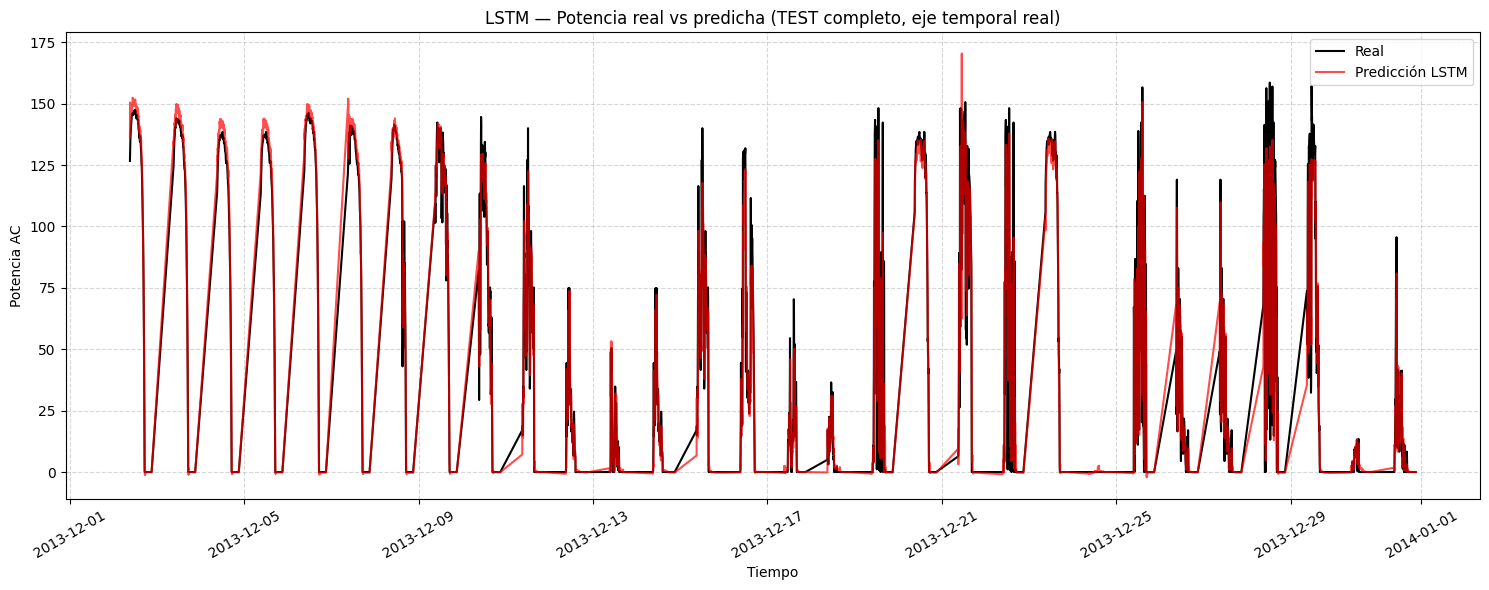


RESULTADOS FINALES: {'mae': 5.9392333339993595, 'rmse': np.float64(13.407431599242342), 'r2': 0.9412396429849522}


In [ ]:
results = main_pipeline(DATA_DF, lookback=LOOKBACK_DEFAULT, n_search_iter=RANDOM_SEARCH_ITERS, verbose=VERBOSE)
print("\nRESULTADOS FINALES:", results["test_metrics"])
#este codigo demora 2 horas corriendo

El modelo LSTM mostró un desempeño sólido pero inferior al de los enfoques basados en árboles, obteniendo un RMSE de 13.40, MAE de 5.94 y un R² de 0.94 en el conjunto de prueba, lo cual indica que logra capturar adecuadamente la forma general de la curva de potencia, aunque con mayor error en periodos de alta variabilidad. Durante la optimización mediante Random Search con TimeSeriesSplit, el conjunto de hiperparámetros más eficiente fue: 128 unidades LSTM, 1 capa, dropout de 0.3, batch size de 64, learning rate de 0.001 y 40 épocas, alcanzando un RMSE promedio de 15.14 en validación cruzada temporal. El análisis de ajuste evidenció un comportamiento de underfitting, ya que el RMSE de entrenamiento (16.04) fue superior al de validación (10.98), lo que sugiere que el modelo no alcanzó toda su capacidad predictiva y requeriría más épocas o mayor complejidad para aprender completamente la dinámica temporal. Gráficamente, la serie predicha sigue adecuadamente los ciclos diarios de generación y reproduce la forma característica de los picos solares, aunque se observan desviaciones en transiciones abruptas. En conjunto, los resultados indican que el LSTM captura la estructura temporal de la potencia, pero aún presenta margen de mejora en precisión fina debido a su entrenamiento conservador y a la complejidad inherente de la serie.

#Conclusiones generales de los resultados obtenidos

Los resultados muestran que, aunque la red LSTM alcanzó un desempeño aceptable (R² ≈ 0.94), su error relativamente alto (RMSE ≈ 13.4) evidencia mayor dispersión respecto a los valores reales. El análisis del ajuste evidenció underfitting, dado que el error en entrenamiento fue superior al de validación, sugiriendo una capacidad insuficiente del modelo o falta de épocas, un fenómeno común en series con patrones diarios complejos como las curvas de generación solar.

En contraste, el modelo Random Forest (RF) obtuvo el mejor desempeño global, con un RMSE notablemente menor (5.25) y un R² de 0.9915, indicando una casi perfecta capacidad explicativa. Estos resultados están ampliamente respaldados por estudios que muestran que los métodos basados en árboles (en particular Random Forest) superan consistentemente a las redes neuronales en el pronóstico de potencia fotovoltaica de corto plazo debido a su robustez, menor sensibilidad a ruido y su habilidad natural para capturar interacciones no lineales sin necesidad de entrenamiento secuencial [2]. Adicionalmente, RF evita el sobreajuste gracias a la agregación de múltiples árboles independientes, e incluso existe evidencia teórica de que el sobreajuste no aumenta al incrementar el número de árboles [3]. La estabilidad entre las métricas de entrenamiento y prueba confirma esta fuerte generalización.

Desde la perspectiva de la dinámica de la serie temporal, el RF captura mejor transiciones abruptas en la potencia —por ejemplo, la aparición repentina de nubes—, mientras que la LSTM muestra el efecto de rezago característico reportado en la literatura, donde las predicciones tienden a reaccionar tarde ante cambios bruscos [4]. Su buen desempeño también se explica por el uso de variables derivadas (lags, rolling windows, estadísticos temporales), que son especialmente efectivas en modelos basados en árboles y reducen la necesidad de arquitecturas profundas [5].

En conjunto, los resultados indican que Random Forest es el modelo más adecuado para este proyecto, dada su alta precisión, estabilidad y excelente generalización con los datos disponibles. La LSTM muestra potencial para mejorar con mayor profundidad temporal y mayor volumen de datos, pero en este escenario específico su rendimiento quedó por debajo del RF, lo cual es completamente consistente con los hallazgos académicos previos. Ridge Regression, por su parte, funciona como un buen modelo base pero carece de la capacidad para capturar las relaciones no lineales presentes en la generación fotovoltaica.

#Referencias

[1] A. Géron, Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow, 2nd ed. Sebastopol, CA, USA: O’Reilly Media, 2019.

[2] N. Berlanger, N. van Ophoven, T. Verdonck, and I. Wilms, “Tree-Based Forecasting of Day-Ahead Solar Power Generation from Granular Meteorological Features,” Data Science in Science, vol. 3, no. 1, 2024. doi: 10.1080/26941899.2024.2426786.

[3] M. Yang, M. Zhao, D. Liu, M. Ma, and X. Su, “Improved Random Forest Method for Ultra-Short-Term Prediction of the Output Power of a Photovoltaic Cluster,” *Frontiers in Energy Research*, vol. 9, Oct. 2021. doi: 10.3389/fenrg.2021.749367.

[4] H. Wu, “Comparison of Random Forest and LSTM in Stock Prediction,” *Advances in Economics, Management and Political Sciences*, vol. 86, pp. 28–34, 2024.

[5] C. G. Villegas-Mier, J. Rodriguez-Resendiz, J. M. Álvarez-Alvarado, H. Jiménez-Hernández, and Á. Odry, “Optimized Random Forest for Solar Radiation Prediction Using Sunshine Hours,” *Micromachines*, vol. 13, no. 9, p. 1406, Aug. 2022. doi: 10.3390/mi13091406.

